# Final Project
## Does Alcohol Consumption Affect Depression Among High School Students?

**Dataset:** YRBS 2007

### Research Question
Does alcohol consumption increase the likelihood of feeling sad or hopeless among high school students?

### Hypothesis
- H0: Alcohol consumption has no relationship with depression tendency.
- H1: Higher alcohol consumption is associated with higher depression tendency.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv('YRBS_2007.csv')
df.head()


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030


## Data Selection and Cleaning

In [16]:
# Independent Variable
x = 'CurrentAlcoholUse'

# Dependent Variable
y = 'SadOrHopeless'

data = df[[x, y]].copy()

data = data.dropna()

print(data.shape)
data.head()


(12610, 2)


,CurrentAlcoholUse,SadOrHopeless
3,1.0,1.0
5,1.0,2.0
6,1.0,2.0
7,1.0,2.0
8,1.0,2.0


### Variable Description

**CurrentAlcoholUse**
- Frequency of alcohol consumption during the past 30 days

**SadOrHopeless**
- Felt sad or hopeless for two weeks or more during the past 12 months


In [17]:
print(data.describe())


       CurrentAlcoholUse  SadOrHopeless
count       12610.000000   12610.000000
mean            1.904124       1.706186
std             1.293697       0.455526
min             1.000000       1.000000
25%             1.000000       1.000000
50%             1.000000       2.000000
75%             2.000000       2.000000
max             7.000000       2.000000


## Exploratory Data Analysis

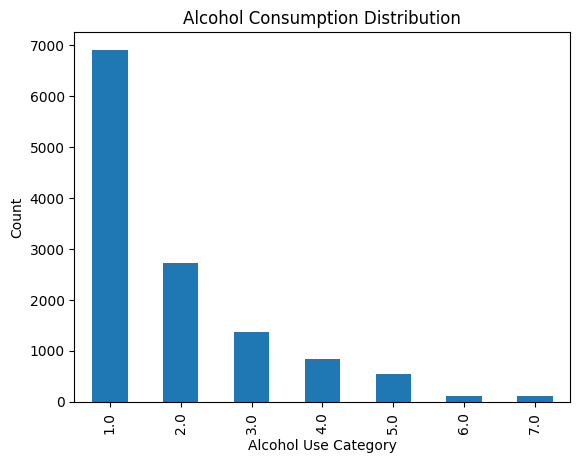

In [18]:
data[x].value_counts().sort_index().plot(kind='bar')
plt.title('Alcohol Consumption Distribution')
plt.xlabel('Alcohol Use Category')
plt.ylabel('Count')
plt.show()


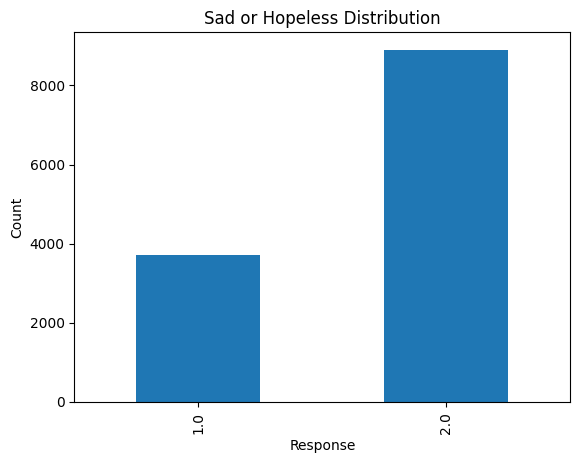

In [19]:
data[y].value_counts().sort_index().plot(kind='bar')
plt.title('Sad or Hopeless Distribution')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()


## Regression Analysis

In [20]:
X = sm.add_constant(data[x])
Y = data[y]

model = sm.OLS(Y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          SadOrHopeless   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     203.4
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           8.69e-46
Time:                        09:12:08   Log-Likelihood:                -7876.1
No. Observations:               12610   AIC:                         1.576e+04
Df Residuals:                   12608   BIC:                         1.577e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.7907      0.00

## Visualization of Relationship

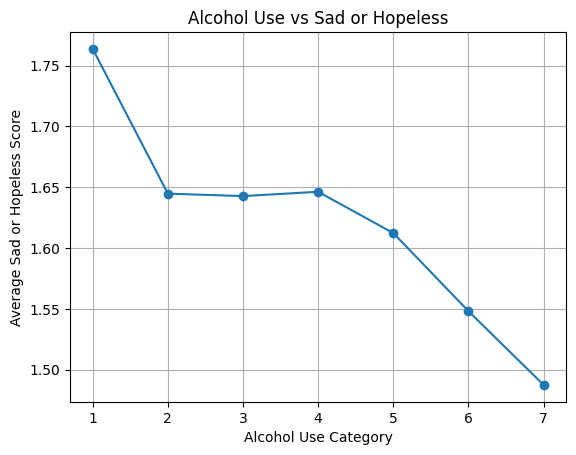

In [21]:
group_mean = data.groupby(x)[y].mean()

group_mean.plot(marker='o')
plt.title('Alcohol Use vs Sad or Hopeless')
plt.xlabel('Alcohol Use Category')
plt.ylabel('Average Sad or Hopeless Score')
plt.grid(True)
plt.show()


## Interpretation

Look at:

- Coefficient of CurrentAlcoholUse
- p-value
- R-squared

If the coefficient is positive and p-value < 0.05, alcohol consumption is significantly associated with higher depression tendency.


## Results

The regression analysis showed a statistically significant relationship between alcohol consumption and depression tendency among high school students.

The coefficient for CurrentAlcoholUse was -0.0444 (p < 0.001), indicating that students who consumed alcohol more frequently were more likely to report feeling sad or hopeless.

The model was statistically significant, F(1,12608) = 203.4, p < 0.001.

Although the R-squared value was 0.016, suggesting that alcohol consumption explains a relatively small portion of the variation in depression tendency, the relationship remains statistically significant.

These findings suggest that alcohol consumption is associated with an increased likelihood of experiencing depressive symptoms among adolescents.



## Discussion

The findings indicate that alcohol consumption is significantly associated with depression among high school students.

One possible explanation is that alcohol may negatively affect emotional regulation and psychological well-being. Students who consume alcohol more frequently may experience greater emotional distress.

Another explanation is that students who already feel sad or hopeless may use alcohol as a coping mechanism. Therefore, the relationship between alcohol consumption and depression may be bidirectional.

Although alcohol consumption alone explains only a small portion of depression tendency, the significant relationship suggests that alcohol use should be considered an important risk factor for adolescent mental health.


## Conclusion

This study examined the relationship between alcohol consumption and depression among high school students using the YRBS 2007 dataset.

The regression results revealed a statistically significant association between alcohol use and depression tendency. Students who consumed alcohol more frequently were more likely to report feeling sad or hopeless.

These findings highlight the importance of alcohol prevention programs and mental health education in schools. Future studies may include additional variables, such as gender, academic performance, and physical activity, to better understand adolescent mental health.
